# How in Python: scopeinpython (soil, canopy BRDF, energy balance, fluorescence)

The SCOPEinR-specific companion to `How-in-Python.ipynb` (which covers `toolsrtm`'s leaf/canopy models alone). SCOPE (Soil Canopy Observation, Photochemistry and Energy fluxes) couples soil reflectance, canopy optical BRDF, leaf photosynthesis, and a full energy-balance closure loop into one simulation -- given one LUT input row, `get_scope()` returns TOC reflectance, converged leaf/soil temperatures, energy fluxes, and (optionally) canopy-level fluorescence, all as one clean `ScopeResult` dataclass (unlike the R version's raw nested-list output -- see the R version of this tutorial, `How-in-R-SCOPEinR.Rmd`, for that structure).

## 1. Load the package

In [1]:
import csv
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scopeinpython import ScopeOptions, get_scope, get_spectra_scope

## 2. Run one full SCOPE simulation

Load SCOPEinR's own bundled example LUT row and run the full leaf optics -> soil -> optical BRDF -> energy balance -> fluorescence pipeline in one `get_scope()` call.

In [2]:
ROOT = Path.cwd().parent  # Tutorials/ -> repo root
LUT_CSV = ROOT / "SCOPEinR" / "inst" / "input" / "LUT_input.csv"

with open(LUT_CSV, newline="") as f:
    row = next(csv.DictReader(f))

result = get_scope(row, options=ScopeOptions(calc_fluor=True, calc_xanthophyllabs=True))

print(f"Canopy layers: {result.nlayers}")
print(f"TOC reflectance at 550nm: {result.rtmo.refl[550 - 400]:.4f}")
print(f"TOC reflectance at 800nm: {result.rtmo.refl[800 - 400]:.4f}")
print(f"Canopy-average leaf temperature (Tcave): {result.ebal.Tcave:.2f} degC")
print(f"Soil temperature, sunlit/shaded: {result.ebal.Tsu:.2f} / {result.ebal.Tsh:.2f} degC")
print(f"Net radiation, total (Rntot): {result.ebal.Rntot:.1f} W/m2")
print(f"Latent heat flux, total (lEtot): {result.ebal.lEtot:.1f} W/m2")
print(f"Sensible heat flux, total (Htot): {result.ebal.Htot:.1f} W/m2")
print(f"Canopy photosynthesis (Actot): {result.ebal.Actot:.2f} umol m-2 s-1")
print(f"Energy-balance convergence: {result.ebal.counter} iterations")
if result.rtmf is not None:
    print(f"Canopy fluorescence flux (EoutF): {result.rtmf.EoutF:.4f} W/m2")
    print(f"F685/F740: {result.rtmf.F685:.3f} / {result.rtmf.F740:.3f}")

Canopy layers: 30
TOC reflectance at 550nm: 0.0438
TOC reflectance at 800nm: 0.3588
Canopy-average leaf temperature (Tcave): 22.04 degC
Soil temperature, sunlit/shaded: 39.85 / 23.79 degC
Net radiation, total (Rntot): 495.5 W/m2
Latent heat flux, total (lEtot): 181.2 W/m2
Sensible heat flux, total (Htot): 274.7 W/m2
Canopy photosynthesis (Actot): 19.89 umol m-2 s-1
Energy-balance convergence: 7 iterations
Canopy fluorescence flux (EoutF): 0.3889 W/m2
F685/F740: 0.311 / 1.808


C:\Users\camin001\OneDrive - Wageningen University & Research\Workspace\0-RTM-Suite\python\scopeinpython\src\scopeinpython\rtmo.py:490: RuntimeWarning: invalid value encountered in divide
  rso = piLou_ / Esun_


**Field lookup** (Python's `ScopeResult` is cleanly split into `result.rtmo`/`.ebal`/`.rtmf` sub-results, unlike R's flat `data.rad`/`data.thermal`/`data.fluxes` naming):

| What you want | Where it is |
|---|---|
| TOC reflectance (full spectrum) | `result.rtmo.refl` |
| Bi-hemispherical / directional components | `result.rtmo.rdd` / `.rsd` / `.rdo` / `.rso` |
| Wavelength grid for the above | `get_spectra_scope().wlS` (400-2400nm @ 1nm, then coarser -- NOT uniform 1nm throughout) |
| Fluorescence spectrum | `result.rtmf.LoF_`, on `get_spectra_scope().wlF` (640-850nm @ 1nm) |
| Sunlit/shaded leaf temperature per layer | `result.ebal.Tcu` / `.Tch` (length = `result.nlayers`) |
| Soil temperature | `result.ebal.Tsu` / `.Tsh` |
| Energy-balance totals | `result.ebal.Rntot` / `.lEtot` / `.Htot` / `.Gtot` |

## 3. Explore the outputs: reflectance, fluorescence, temperature, fluxes

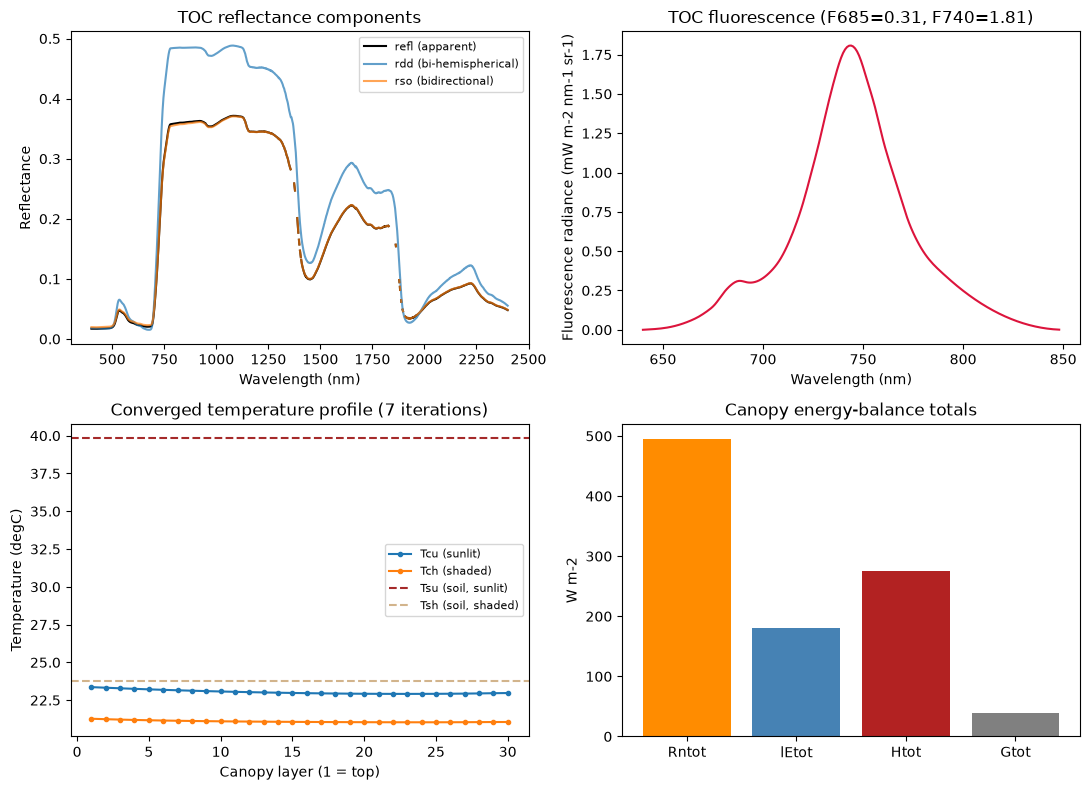

In [3]:
wl_optical = np.arange(400, 2401)  # the uniform-1nm part of rtmo's grid
n = len(wl_optical)

fig, axes = plt.subplots(2, 2, figsize=(11, 8))

ax = axes[0, 0]
ax.plot(wl_optical, result.rtmo.refl[:n], label="refl (apparent)", color="black")
ax.plot(wl_optical, result.rtmo.rdd[:n], label="rdd (bi-hemispherical)", alpha=0.7)
ax.plot(wl_optical, result.rtmo.rso[:n], label="rso (bidirectional)", alpha=0.7)
ax.set_xlabel("Wavelength (nm)"); ax.set_ylabel("Reflectance")
ax.set_title("TOC reflectance components"); ax.legend(fontsize=8)

ax = axes[0, 1]
wl_f = get_spectra_scope().wlF
ax.plot(wl_f, result.rtmf.LoF_, color="crimson")
ax.set_xlabel("Wavelength (nm)"); ax.set_ylabel("Fluorescence radiance (mW m-2 nm-1 sr-1)")
ax.set_title(f"TOC fluorescence (F685={result.rtmf.F685:.2f}, F740={result.rtmf.F740:.2f})")

ax = axes[1, 0]
layers = np.arange(1, result.nlayers + 1)
ax.plot(layers, result.ebal.Tcu, label="Tcu (sunlit)", marker=".")
ax.plot(layers, result.ebal.Tch, label="Tch (shaded)", marker=".")
ax.axhline(result.ebal.Tsu, color="brown", linestyle="--", label="Tsu (soil, sunlit)")
ax.axhline(result.ebal.Tsh, color="tan", linestyle="--", label="Tsh (soil, shaded)")
ax.set_xlabel("Canopy layer (1 = top)"); ax.set_ylabel("Temperature (degC)")
ax.set_title(f"Converged temperature profile ({result.ebal.counter} iterations)"); ax.legend(fontsize=8)

ax = axes[1, 1]
fluxes = {"Rntot": result.ebal.Rntot, "lEtot": result.ebal.lEtot, "Htot": result.ebal.Htot, "Gtot": result.ebal.Gtot}
ax.bar(fluxes.keys(), fluxes.values(), color=["darkorange", "steelblue", "firebrick", "grey"])
ax.set_ylabel("W m-2"); ax.set_title("Canopy energy-balance totals")

fig.tight_layout(); plt.show()

![](images/scope_energy_balance.png)

## 4. Many simulations (100-row LUT)

`get_scope()` is much more expensive per call than `toolsrtm.foursail()` (dominated by the energy-balance nonlinear solve, ~0.1-0.3s per call vs ~2ms, so 100 rows takes on the order of a minute) -- this tutorial perturbs Cab, LAI, EWT and Vcmax25 around the example row -- see `Scripts/Python/ForSCOPE_Python/3_simulate_lut.py` for the same idea at production scale with more recorded outputs.

In [ ]:
rng = np.random.default_rng(42)
options = ScopeOptions(calc_fluor=True, calc_xanthophyllabs=False)  # xanthophyll off: keep the loop fast
N_SAMPLES = 100

rows = []
for i in range(N_SAMPLES):
    row_i = dict(row)
    row_i["Cab"] = float(rng.uniform(15, 65))
    row_i["LAI"] = float(rng.uniform(0.5, 6.0))
    row_i["EWT"] = float(rng.uniform(0.005, 0.025))
    row_i["Vcmax25"] = float(rng.uniform(20, 200))
    result_i = get_scope(row_i, options=options)
    rows.append({
        "Cab": row_i["Cab"], "LAI": row_i["LAI"], "EWT": row_i["EWT"], "Vcmax25": row_i["Vcmax25"],
        "Actot": result_i.ebal.Actot, "EoutF": result_i.rtmf.EoutF, "result": result_i,
    })

lut_df = pd.DataFrame(rows).drop(columns="result")

fig, axes = plt.subplots(1, 2, figsize=(11, 5))
axes[0].scatter(lut_df["Vcmax25"], lut_df["Actot"], color="#2166AC")
axes[0].set_xlabel("Vcmax25 (umol m-2 s-1)"); axes[0].set_ylabel("Canopy photosynthesis, Actot (umol m-2 s-1)")
axes[0].set_title("Actot vs Vcmax25")
axes[1].scatter(lut_df["Cab"], lut_df["EoutF"], color="#B2182B")
axes[1].set_xlabel("Cab"); axes[1].set_ylabel("Canopy fluorescence flux, EoutF (W/m2)")
axes[1].set_title("SIF vs Cab")
fig.tight_layout(); plt.show()

`Vcmax25` (maximum carboxylation capacity) is the direct physiological driver of `Actot` in SCOPE's Farquhar-type photosynthesis model, so across 100 randomly-drawn rows the relationship comes through clearly. The right panel shows the other half of what makes scopeinpython more than plain `toolsrtm`: fluorescence (`EoutF`) is sensitive to leaf pigments, not just to LAI/structure -- substitute `lut_df["Cab"]` for another pigment column to see the same fluorescence output against a different one.

## 5. Trait inversion with machine learning

The reverse problem: given ONLY the sensor-band reflectance a satellite would actually measure, retrieve a trait (LAI here -- the classic structural retrieval target) without knowing the ground truth. Convolve each of the 100 simulations' apparent reflectance (`result.rtmo.refl`, Section 3) onto Sentinel-2A's bands, then train on 70% of the rows and evaluate on the 30% the model never saw:

In [ ]:
from toolsrtm.srf import srf_sentinel2a, spectral_convolution_srf
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, root_mean_squared_error

sensor = srf_sentinel2a()

def convolve_reflapp(result_i):
    rfl_i = result_i.rtmo.refl[:n].copy()
    # refl is a radiance ratio, and incident irradiance is genuinely
    # near-zero at a handful of water-vapor/O2 absorption wavelengths
    # (~1355-1420, ~1800-1950nm) -- numerically unstable there in every
    # simulation, not just unusual random draws (real sensors avoid
    # placing bands on these features for the same reason). Linearly
    # interpolate over just those narrow gaps before convolving.
    bad = ~np.isfinite(rfl_i)
    if bad.any():
        rfl_i[bad] = np.interp(wl_optical[bad], wl_optical[~bad], rfl_i[~bad])
    return spectral_convolution_srf(wl_optical, rfl_i, sensor).rfl

band_refl = np.array([convolve_reflapp(r["result"]) for r in rows])
X_train, X_test, y_train, y_test = train_test_split(
    band_refl, lut_df["LAI"], test_size=0.3, random_state=1)

rf = RandomForestRegressor(n_estimators=300, random_state=1)
rf.fit(X_train, y_train)
pred = rf.predict(X_test)
print("R2:", r2_score(y_test, pred), " RMSE:", root_mean_squared_error(y_test, pred))

plt.figure(figsize=(6, 6))
plt.scatter(y_test, pred, color="#2166AC")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color="grey", linestyle="--")
plt.xlabel("Observed LAI"); plt.ylabel("Predicted LAI")
plt.title("LAI retrieved from Sentinel-2A bands (SCOPE refl)")
plt.show()

Same interface as `How-in-Python.ipynb`'s own step 6 (RandomForest on convolved sensor bands) -- what changes here is the input spectrum: `refl` comes out of the full energy-balance/fluorescence-coupled SCOPE run instead of plain PROSAIL, so this trains on what a sensor would see over a canopy whose leaf/soil temperatures were actually solved for, not assumed.

## What's not covered here (and why)

- **Batch LUT runs at course-pipeline scale (N=1000+)** -- see `Scripts/Python/ForSCOPE_Python/1_run_scope.py`/`2_explore_outputs.py`/`3_simulate_lut.py` for the standalone script versions with saved CSV outputs.

See [`CCGCAM/RTM-Suite`](https://github.com/CCGCAM/RTM-Suite) for the full course materials and the R/Python numerical verification writeup (`python/README.md`).